# Download de bibliotecas

In [43]:
!pip install numpy==1.23.5 pandas==2.2.2

In [44]:
!pip install pmdarima

# Importando dados

In [45]:
import pandas as pd
import os
import numpy as np
from google.colab import drive

drive.mount('/content/drive')

caminho_dados = '/content/drive/Shareddrives/IC - Otimizacao computacional para inflacao/Dados'

# Listar os arquivos dentro da pasta "Dados"
arquivos_dados = os.listdir(caminho_dados)

print(arquivos_dados)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['df_macro.csv', 'dados_macro.ipynb']


In [46]:
file_path = os.path.join(caminho_dados, 'df_macro.csv')

df = pd.read_csv(file_path, index_col='Date', parse_dates=True)


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 154 entries, 2012-03-01 to 2024-12-01
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   IPCA                                   154 non-null    float64
 1   IPCA_Transportes                       154 non-null    float64
 2   IPCA Alimentação_bebidas               154 non-null    float64
 3   INPC_Habitação                         154 non-null    float64
 4   IPCA_Saúde_cuidados_pessoais           154 non-null    float64
 5   IPCA_Vestuário                         154 non-null    float64
 6   IPCA_Educação                          154 non-null    float64
 7   IPCA_Despesas_Pessoais                 154 non-null    float64
 8   USDBRL                                 154 non-null    float64
 9   Reservas Internacionais                154 non-null    int64  
 10  Desemprego                             154 non-null    

In [48]:
df.head()

,IPCA,IPCA_Transportes,IPCA Alimentação_bebidas,INPC_Habitação,IPCA_Saúde_cuidados_pessoais,IPCA_Vestuário,IPCA_Educação,IPCA_Despesas_Pessoais,USDBRL,Reservas Internacionais,...,IPC_BR,Produção_Derivados_Petróleo,Consumo_Gasolina,Consumo_Óleo_Combustível,Consumo_Energia_Comercial,Consumo_Energia_Residencial,Consumo_Energia_Total,Estoque_Empregos_Formais_Total,Estoque_Empregos_Formais_Agropecuária,Estoque_Empregos_Formais_Construção
Date,,,,,,,,,,,,,,,,,,,,,
2012-03-01,-0.08,0.16,0.25,0.43,0.38,-0.61,0.54,0.55,1.8221,365216,...,0.60,2169,537,59,7037,10271,38636,38754453,1470766,2910763
2012-04-01,0.55,0.10,0.51,0.73,0.96,0.98,0.04,2.23,1.8918,374272,...,0.52,2106,531,64,6856,9928,37996,39018063,1495548,2963001
2012-05-01,0.49,-0.58,0.73,0.82,0.66,0.89,-0.01,0.60,2.0223,372409,...,0.52,2136,527,61,6417,9532,36810,39213837,1549189,2989022
2012-06-01,-0.31,-1.18,0.68,0.24,0.38,0.39,0.06,0.47,2.0213,373910,...,0.11,2127,538,58,6282,9605,36528,39377064,1614204,3000347
2012-07-01,0.06,-0.03,0.91,0.51,0.36,0.04,0.12,0.91,2.0499,376154,...,0.22,2116,527,62,6033,9274,35917,39561060,1641519,3034369


# Funcoes auxiliares

In [49]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import joblib

# Funções auxiliares

def make_stationary(df, max_diff=5):
    """Torna a série temporal estacionária através de diferenciação."""
    df_diff = df.copy()
    for i in range(1, max_diff + 1):
        stationary = True
        for column in df_diff.columns:
            if not check_stationarity(df_diff[[column]]):
                stationary = False
                df_diff[[column]] = df_diff[[column]].diff().fillna(method='ffill').fillna(method='bfill')
        if stationary:
            print(f"Série estacionária após {i-1} diferenciações.")
            return df_diff.dropna()
    raise ValueError("A série não se tornou estacionária após o número máximo de diferenciações.")

def check_stationarity(series, significance_level=0.05):
    """Verifica se a série é estacionária usando o teste ADF."""
    from statsmodels.tsa.stattools import adfuller
    result = adfuller(series.dropna())
    return result[1] < significance_level

def plot_forecasts(y_test, final_forecast, title='Previsão Dinâmica'):
    """Plota as previsões comparadas com os valores reais."""
    plt.figure(figsize=(15, 3))
    plt.plot(y_test.index, y_test, label='Valores Reais', color='blue')
    plt.plot(y_test.index, final_forecast, label='Previsão', color='orange')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# Hibrido (Arimax + RF)

In [50]:
import warnings
warnings.filterwarnings('ignore')

In [51]:
from sklearn.ensemble import RandomForestRegressor # Import RandomForestRegressor here
import matplotlib.pyplot as plt

In [52]:
random_state = 42

In [53]:
def executar_modelo_arimax_hibrido(df, exogenous_vars,tecnica_nome):
    # Tornar o DataFrame estacionário
    df_stationary = make_stationary(df[['IPCA'] + exogenous_vars])

    # Dividir em treino e teste
    train_size = int(len(df_stationary) * 0.8)
    train, test = df_stationary.iloc[:train_size], df_stationary.iloc[train_size:]

    # Variável dependente e exógenas
    y_train = train['IPCA']
    y_test = test['IPCA']
    X_train = train[exogenous_vars]
    X_test = test[exogenous_vars]

    # Ajustar modelo ARIMAX com auto_arima
    arimax_model = auto_arima(y_train, exogenous=X_train, seasonal=False, trace=True,
                               error_action='ignore', suppress_warnings=True)
    arimax_order = arimax_model.order

    # Previsão dinâmica com atualização a cada passo
    dynamic_arimax_forecast = []
    history_y = list(y_train)
    history_X = list(X_train.values)

    for t in range(len(y_test)):
        model = SARIMAX(history_y, exog=np.array(history_X), order=arimax_order)
        fitted_model = model.fit(disp=False)
        next_x = X_test.iloc[t].values.reshape(1, -1)
        forecast = fitted_model.forecast(steps=1, exog=next_x)
        dynamic_arimax_forecast.append(forecast[0])
        history_y.append(y_test.iloc[t])
        history_X.append(X_test.iloc[t].values)

    # Calcular resíduos
    residuals = y_test.values - dynamic_arimax_forecast

    # Treinar modelo Random Forest para prever os resíduos
    rf_model = RandomForestRegressor(n_estimators=100, random_state=random_state)
    rf_model.fit(X_test.reset_index(drop=True), residuals)

    # Previsão dos resíduos com Random Forest
    predicted_residuals_rf = rf_model.predict(X_test.reset_index(drop=True))

    # Previsão híbrida: ARIMAX + RF
    hybrid_forecast = np.array(dynamic_arimax_forecast) + predicted_residuals_rf

    # Métricas de desempenho
    mse = mean_squared_error(y_test, hybrid_forecast)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, hybrid_forecast)
    mape = np.mean(np.abs((y_test - hybrid_forecast) / y_test))

    print(f'MAE: {mae:.6f}')
    print(f'MSE: {mse:.6f}')
    print(f'RMSE: {rmse:.6f}')
    print(f'MAPE: {mape:.6f}')

    # Plotar resultados
    plot_forecasts(y_test, hybrid_forecast, title=f'{tecnica_nome} (ARIMAX + Random Forest)')

# Implementacao

5 features - GA

Série estacionária após 2 diferenciações.
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=126.122, Time=0.66 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=262.064, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=135.136, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=193.641, Time=0.11 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=125.469, Time=0.47 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=175.043, Time=0.10 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=127.149, Time=0.07 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=127.251, Time=0.16 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=157.652, Time=0.34 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=124.310, Time=0.89 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=130.885, Time=0.10 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=129.513, Time=0.72 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=127.620, Time=0.38 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=127.423, Time=5.29 sec
 ARIM

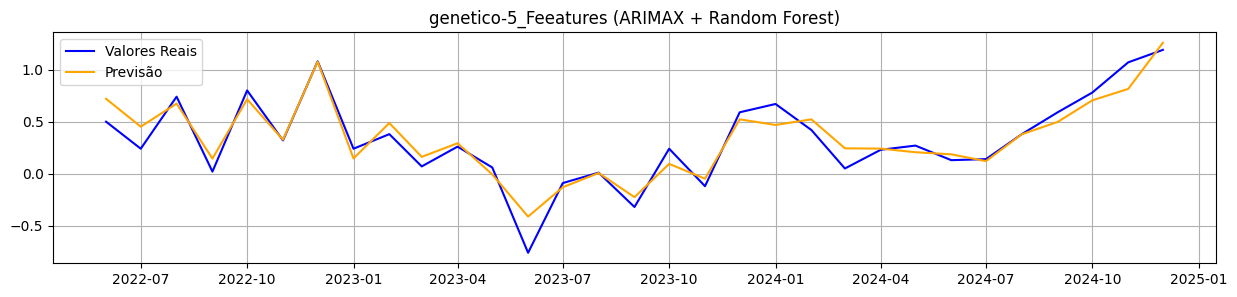

In [54]:
exogenous_vars= ['IPCA_Saúde_cuidados_pessoais', 'IPCA_Vestuário', 'USDBRL', 'Consumo_Energia_Comercial', 'Estoque_Empregos_Formais_Total']
executar_modelo_arimax_hibrido(df,exogenous_vars,'genetico-5_Feeatures')

5 features - PSO

Série estacionária após 2 diferenciações.
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=126.122, Time=0.23 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=262.064, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=135.136, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=193.641, Time=0.09 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=125.469, Time=0.13 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=175.043, Time=0.08 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=127.149, Time=0.07 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=127.251, Time=0.14 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=157.652, Time=0.09 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=124.310, Time=0.26 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=130.885, Time=0.05 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=129.513, Time=0.10 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=127.620, Time=0.08 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=127.423, Time=0.36 sec
 ARIM

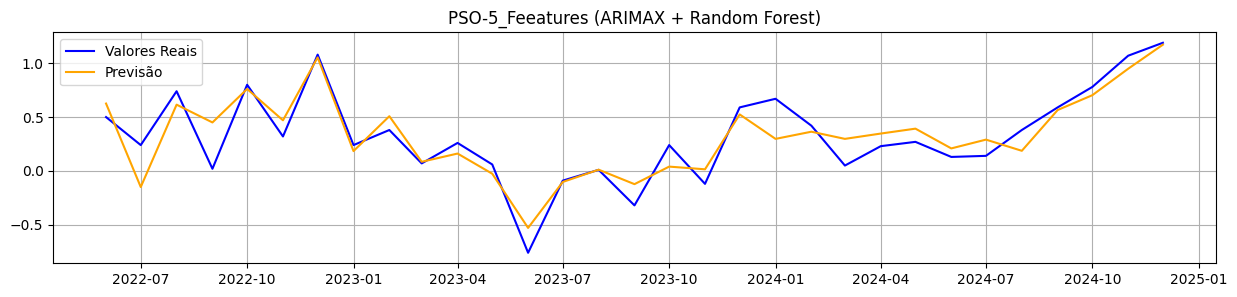

In [55]:
exogenous_vars= ['IPCA_Transportes', 'IGP_DI', 'Produção_Derivados_Petróleo', 'Consumo_Gasolina', 'Estoque_Empregos_Formais_Total']
executar_modelo_arimax_hibrido(df,exogenous_vars,'PSO-5_Feeatures')

Todas as features

Série estacionária após 2 diferenciações.
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=126.122, Time=0.21 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=262.064, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=135.136, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=193.641, Time=0.09 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=125.469, Time=0.12 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=175.043, Time=0.08 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=127.149, Time=0.06 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=127.251, Time=0.17 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=157.652, Time=0.08 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=124.310, Time=0.23 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=130.885, Time=0.05 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=129.513, Time=0.09 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=127.620, Time=0.07 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=127.423, Time=0.35 sec
 ARIM

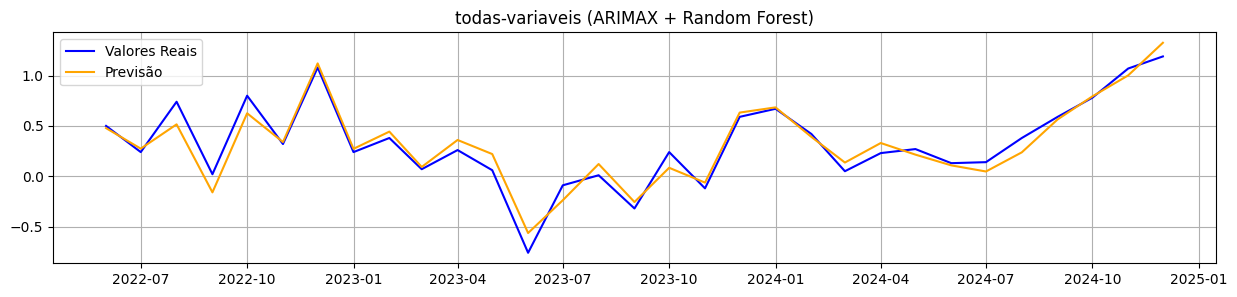

In [56]:
exogenous_vars= ["IPCA_Transportes","IPCA Alimentação_bebidas","INPC_Habitação","IPCA_Saúde_cuidados_pessoais","IPCA_Vestuário","IPCA_Educação","IPCA_Despesas_Pessoais","USDBRL","Reservas Internacionais","Desemprego","SELIC","SalMinimo","PIB Mensal","QteOvos","INPC","IGP_M","IGP_DI","IPC_BR","Produção_Derivados_Petróleo","Consumo_Gasolina","Consumo_Óleo_Combustível","Consumo_Energia_Comercial","Consumo_Energia_Residencial","Consumo_Energia_Total","Estoque_Empregos_Formais_Total","Estoque_Empregos_Formais_Agropecuária","Estoque_Empregos_Formais_Construção"]

executar_modelo_arimax_hibrido(df,exogenous_vars,'todas-variaveis')